In [1]:
import os
os.chdir("..")

from utils.utils import notebook_line_magic
notebook_line_magic()

Line Magic Set


In [59]:
# os.listdir('/home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/cars/train')

In [24]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "eduardo4jesus/stanford-cars-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.82G/1.82G [00:29<00:00, 66.7MB/s]

Extracting files...


Path to dataset files: /home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1


In [96]:
# class StanfordCars(Dataset):
#     def __init__(self, path, transform=None):
#         super(StanfordCars, self).__init__()
#         self.data = datasets.ImageFolder(path, transform)
        
#     def __getitem__(self, idx):
#         x, y = self.data[idx]
        
#     def __len__(self):
#         return len(self.data)

data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(150, 150)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

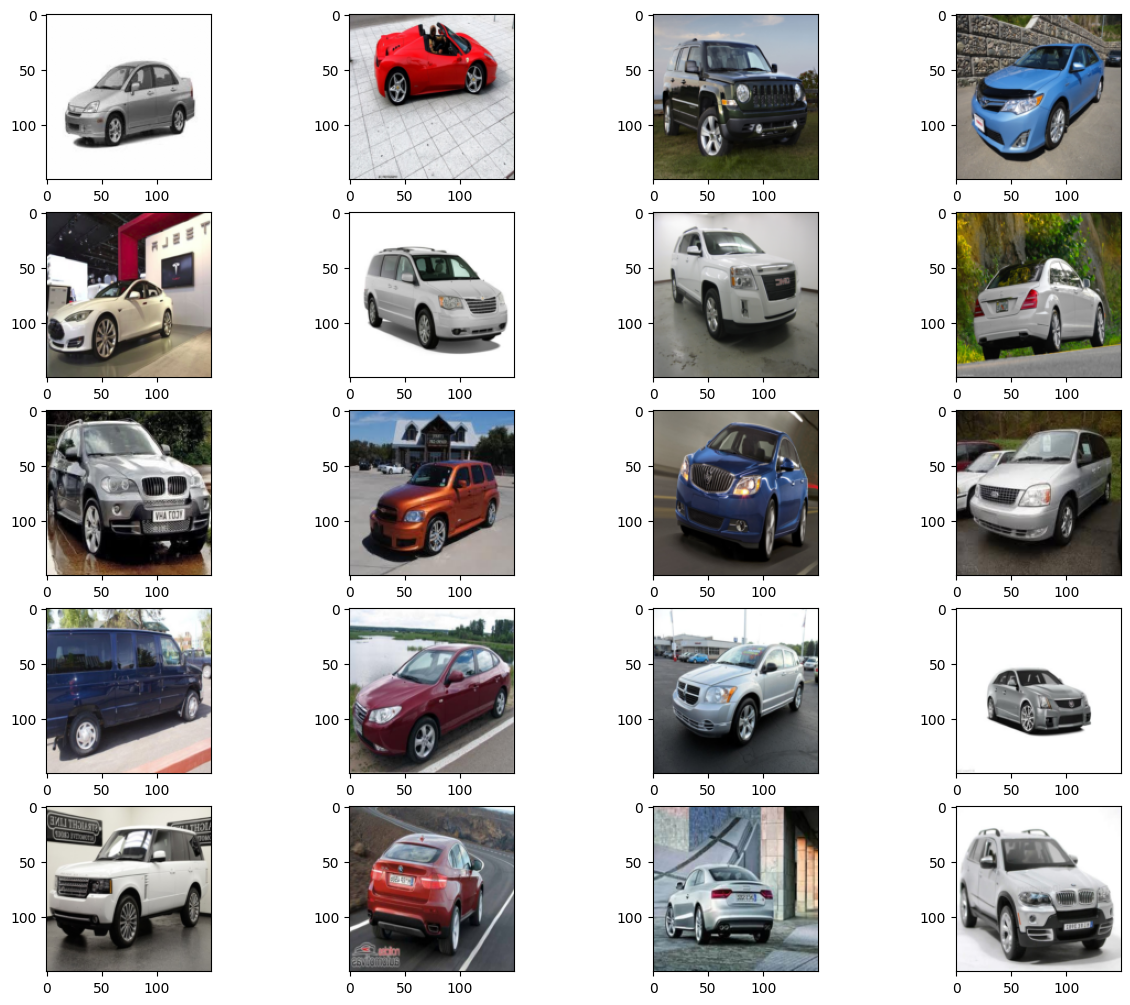

In [97]:
def show_images(dataset, num_samples=20, cols=4):
    """plot images
    """
    plt.figure(figsize=(15,15))
    for i, img in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i +1)
        plt.imshow(img[0].permute(1,2,0))

path = '/home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/cars/'
data = datasets.ImageFolder(
    root=path,
    transform=data_transform
)
train_dataloader = DataLoader(
    dataset=data, 
    batch_size=1, 
    num_workers=1, 
    shuffle=True
)

show_images(data)